# K-Means — Segmentacion de votantes por posiciones politicas

**Objetivo:** Aplicar K-Means a un dataset real de 3.689 votantes con 4 variables de opinion politica para identificar segmentos ideologicos. Incluye radar charts de perfiles, heatmap normalizado y PCA para visualizacion.

**Contexto de negocio:** Un partido politico quiere segmentar a su electorado por posiciones reales (no solo edad o ingresos) para disenar mensajes de campana diferenciados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import os

sns.set_style('whitegrid')
print('Librerias cargadas correctamente')

Librerias cargadas correctamente


## 1. Carga y exploracion del dataset

In [2]:
ruta = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'politicos.xlsx')
df = pd.read_excel(ruta)
print(f'Dataset: {df.shape[0]} registros, {df.shape[1]} variables')
print(f'Columnas: {list(df.columns)}')
display(df.head())
display(df.describe())

Dataset: 3689 registros, 9 variables
Columnas: ['edad', 'ingresos', 'estudios', 'estado_civil', 'seguridad', 'impuestos', 'servicios_publicos', 'inmigracion', 'voto']


,edad,ingresos,estudios,estado_civil,seguridad,impuestos,servicios_publicos,inmigracion,voto
0,61,1690,Postgraduate,Married,3,9,2,1,PP
1,26,1978,Basic,Divorced,1,5,9,1,PSOE
2,68,1547,Postgraduate,Widowed,9,9,10,2,PP
3,31,2937,University,Married,2,4,10,9,PSOE
4,43,2639,University,Divorced,7,1,1,9,VOX


,edad,ingresos,seguridad,impuestos,servicios_publicos,inmigracion
count,3689.000000,3689.000000,3689.000000,3689.000000,3689.000000,3689.000000
mean,48.663594,3015.001355,5.609650,5.554080,5.526159,5.494443
std,18.144033,1157.474329,2.865755,2.846272,2.890243,2.897664
min,18.000000,1000.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,2023.000000,3.000000,3.000000,3.000000,3.000000
50%,48.000000,2999.000000,6.000000,6.000000,5.000000,5.000000
75%,64.000000,4022.000000,8.000000,8.000000,8.000000,8.000000
max,80.000000,5000.000000,10.000000,10.000000,10.000000,10.000000


## 2. Seleccion de variables de opinion

Usamos las 4 variables numericas de posicion politica (escala 1-10). Edad, ingresos, estudios, estado_civil y voto quedan fuera del clustering.

In [3]:
features = ['seguridad', 'impuestos', 'servicios_publicos', 'inmigracion']
print(f'Variables de segmentacion: {features}')

X = df[features].dropna()
print(f'Registros sin nulos: {len(X)}')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Datos estandarizados')

Variables de segmentacion: ['seguridad', 'impuestos', 'servicios_publicos', 'inmigracion']
Registros sin nulos: 3689
Datos estandarizados


## 3. Seleccion de k: codo y silhouette

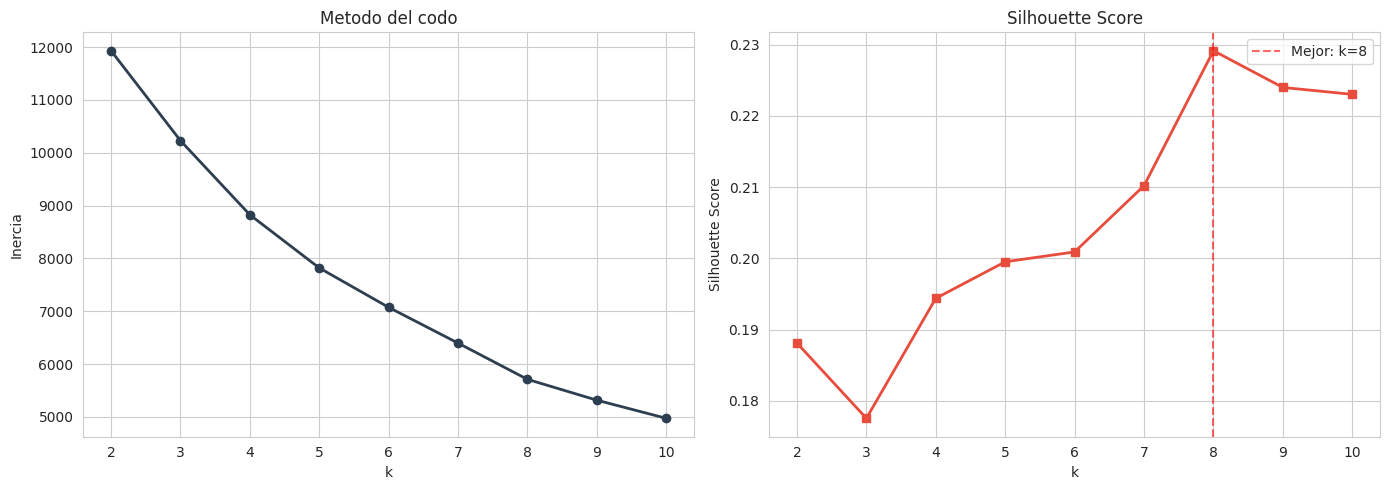

Mejor silhouette: k=8 (0.2292)


In [4]:
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, marker='o', linewidth=2, color='#2c3e50')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Metodo del codo')

axes[1].plot(K_range, silhouettes, marker='s', linewidth=2, color='#e74c3c')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'Mejor: k={best_k}')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f'Mejor silhouette: k={best_k} ({max(silhouettes):.4f})')

## 4. Modelo final

In [5]:
k_final = best_k
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_clean = df.loc[X.index].copy()
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'K-Means con k={k_final}')
for cl in range(k_final):
    n = (df_clean['Cluster'] == cl).sum()
    print(f'  Cluster {cl}: {n} votantes ({n/len(df_clean)*100:.1f}%)')

K-Means con k=8
  Cluster 0: 433 votantes (11.7%)
  Cluster 1: 457 votantes (12.4%)
  Cluster 2: 482 votantes (13.1%)
  Cluster 3: 443 votantes (12.0%)
  Cluster 4: 434 votantes (11.8%)
  Cluster 5: 458 votantes (12.4%)
  Cluster 6: 486 votantes (13.2%)
  Cluster 7: 496 votantes (13.4%)


## 5. Heatmap normalizado de perfiles

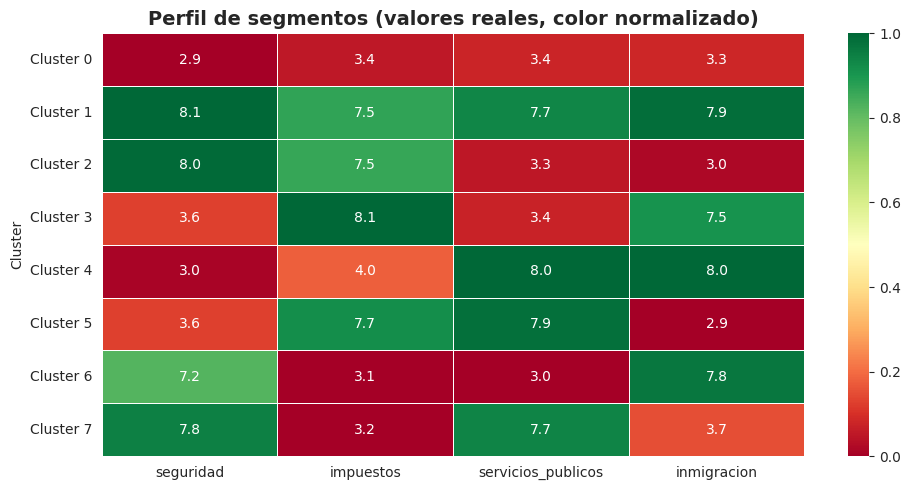

In [6]:
perfil = df_clean.groupby('Cluster')[features].mean()
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(perfil_norm, annot=perfil.round(1).values, fmt='', cmap='RdYlGn',
            xticklabels=features, yticklabels=[f'Cluster {i}' for i in range(k_final)],
            linewidths=0.5, ax=ax)
ax.set_title('Perfil de segmentos (valores reales, color normalizado)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Radar chart por segmento

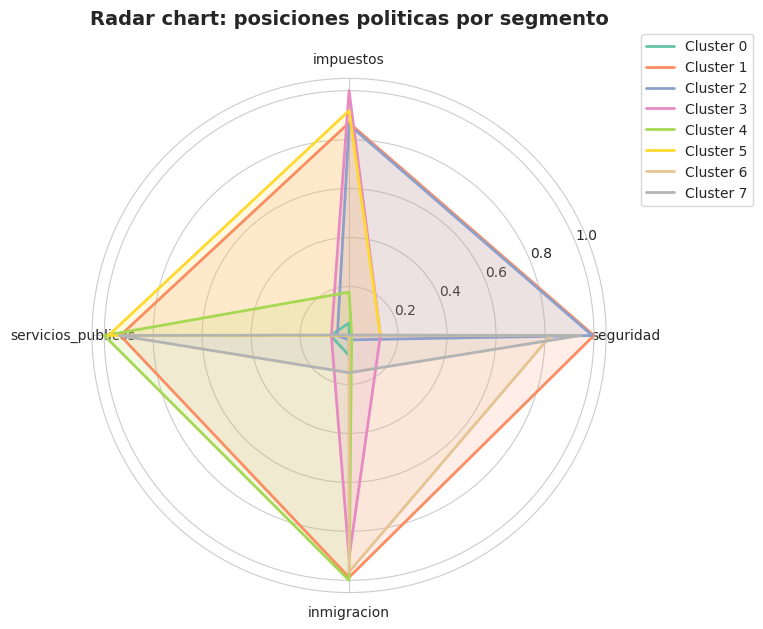

In [7]:
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colores = plt.cm.Set2.colors

for cl in range(k_final):
    vals = perfil_norm.loc[cl].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, label=f'Cluster {cl}', color=colores[cl])
    ax.fill(angles, vals, alpha=0.15, color=colores[cl])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=10)
ax.set_title('Radar chart: posiciones politicas por segmento', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 7. Proyeccion PCA 2D

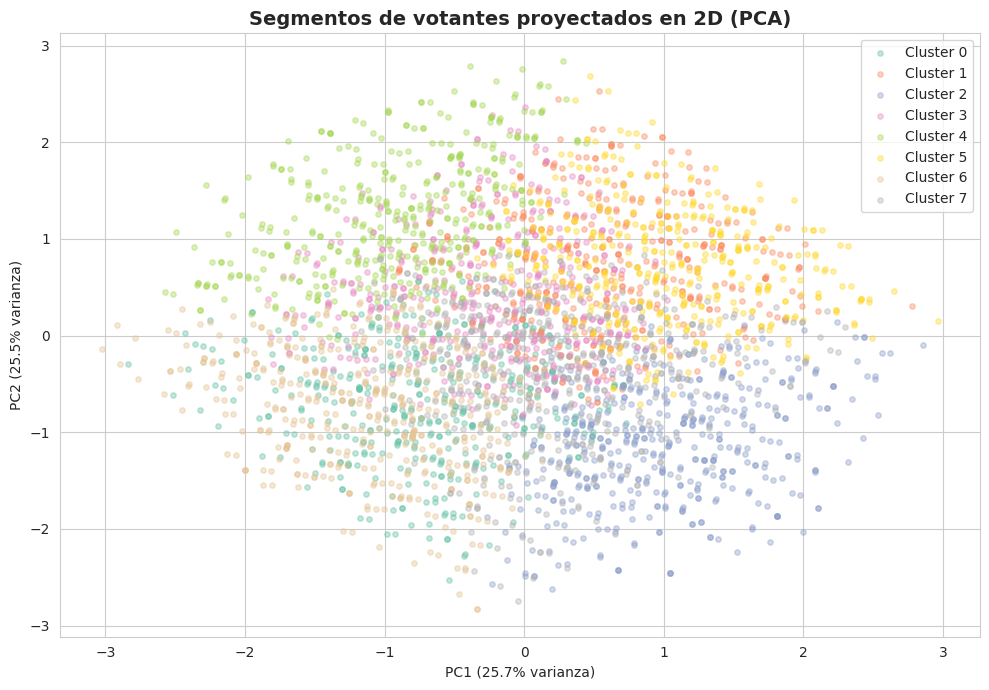

Varianza explicada por PC1+PC2: 51.2%


In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
for cl in range(k_final):
    mask = df_clean['Cluster'] == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=15,
               label=f'Cluster {cl}', color=colores[cl])

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Segmentos de votantes proyectados en 2D (PCA)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Varianza explicada por PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%')

## 8. Cross-check demografico

In [9]:
print('Perfil demografico por cluster:')
display(df_clean.groupby('Cluster')[['edad', 'ingresos']].mean().round(1))

print('\nDistribucion de voto por cluster:')
ct = pd.crosstab(df_clean['Cluster'], df_clean['voto'], normalize='index') * 100
display(ct.round(1))

Perfil demografico por cluster:


,edad,ingresos
Cluster,,
0,48.2,2944.7
1,49.9,3016.8
2,48.6,2946.0
3,49.2,3066.6
4,49.0,2965.3
5,47.9,3023.6
6,49.1,3112.3
7,47.5,3036.0



Distribucion de voto por cluster:


voto,PP,PSOE,VOX
Cluster,,,
0,95.2,4.8,0.0
1,36.8,0.0,63.2
2,96.5,0.0,3.5
3,94.4,0.0,5.6
4,44.7,52.8,2.5
5,86.2,13.8,0.0
6,55.3,0.0,44.7
7,36.7,54.6,8.7


## 9. Conclusiones y recomendaciones

**Hallazgos:**
- K-Means revela segmentos de votantes con combinaciones de posiciones coherentes pero no triviales.
- El radar chart muestra que los segmentos no se alinean en un unico eje izquierda-derecha.
- La proyeccion PCA confirma que los clusters tienen separacion real en el espacio multidimensional.

**Recomendaciones para la campana:**
- Cada segmento requiere un mensaje diferenciado: no vale un discurso unico.
- Los ejes de seguridad e impuestos suelen ser los mas discriminantes.
- Los segmentos con posiciones mixtas son swing voters: maxima atencion.

